In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [54]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [55]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6017,4482-FTFFX,Male,0,No,No,5,Yes,No,DSL,No,...,Yes,Yes,No,No,Month-to-month,No,Electronic check,56.15,291.45,No
442,0206-TBWLC,Female,0,Yes,No,54,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,114.65,6049.5,No
5989,5567-WSELE,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.60,279.55,Yes
471,3583-EKAPL,Male,0,No,No,1,Yes,No,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.00,55,Yes


In [56]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [57]:
df_org.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [58]:
df=df_org.copy()

In [59]:
#churn rate among seniors
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [60]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

multi_cols = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

In [61]:
X = df.drop('Churn', axis=1)
Y = df['Churn']

In [62]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5042,1561-BWHIN,Male,0,Yes,Yes,19,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.80,344.5,No
6605,7632-MNYOY,Male,1,No,No,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),110.90,7432.05,Yes
3035,7924-GJZFI,Female,1,Yes,No,25,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.30,1813.1,No
5484,4419-UJMUS,Male,0,Yes,Yes,69,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Two year,Yes,Electronic check,99.35,6856.45,No
1514,5799-JRCZO,Female,0,No,Yes,63,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.50,1215.1,No
1965,3948-XHGNA,Male,0,No,No,24,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),49.55,1210.4,Yes
5214,2983-ZANRP,Female,0,Yes,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),73.55,145.4,Yes
4744,6139-ZZRBQ,Male,1,No,No,64,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.05,1198.05,No
1172,1641-RQDAY,Female,1,Yes,Yes,32,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,3217.65,No
1257,0723-VSOBE,Female,1,No,No,45,No,No phone service,DSL,No,...,No,No,No,Yes,One year,No,Electronic check,34.20,1596.6,No


In [63]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [64]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)
from sklearn.linear_model import LogisticRegression



num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1,errors='ignore')

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [67]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [68]:
logistic_pipe = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', LogisticRegression())])

In [69]:
# =========================================
# BASIC LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# PREPROCESSING
# =========================================

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (

    StandardScaler,

    OneHotEncoder,

    LabelEncoder,

    FunctionTransformer

)

from sklearn.impute import SimpleImputer

# =========================================
# TRAIN TEST SPLIT
# =========================================

from sklearn.model_selection import (

    train_test_split,

    GridSearchCV

)

# =========================================
# SUPERVISED LEARNING ALGORITHMS
# =========================================

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (

    RandomForestClassifier,

    BaggingClassifier,

    AdaBoostClassifier,

    GradientBoostingClassifier,

    VotingClassifier,

    StackingClassifier

)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

# =========================================
# UNSUPERVISED LEARNING
# =========================================

from sklearn.cluster import (

    KMeans,

    DBSCAN

)

# =========================================
# METRICS
# =========================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report,

    silhouette_score,

    davies_bouldin_score,

    calinski_harabasz_score

)

# =========================================
# VISUALIZATION FOR TREES
# =========================================

from sklearn.tree import plot_tree

In [70]:
models = {

    'Logistic Regression':
        LogisticRegression(),

    'Naive Bayes':
        GaussianNB(),

    'Decision Tree':
        DecisionTreeClassifier(),

    'Random Forest':
        RandomForestClassifier(),

    'SVM':
        SVC()

}

In [74]:
ensemble_models = {

    # -------------------------------------
    # BAGGING
    # -------------------------------------

    'Bagging':

        BaggingClassifier(
            estimator=DecisionTreeClassifier(),
            n_estimators=100,
            random_state=42
        ),

    # -------------------------------------
    # BOOSTING
    # -------------------------------------

    'AdaBoost':

        AdaBoostClassifier(
            n_estimators=100,
            random_state=42
        ),

    'Gradient Boosting':

        GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ),

    # -------------------------------------
    # RANDOM FOREST
    # (Bagging + Random Feature Selection)
    # -------------------------------------

    'Random Forest':

        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    # -------------------------------------
    # VOTING CLASSIFIER
    # -------------------------------------

    'Voting':

        VotingClassifier(

            estimators=[

                ('lr', lr),

                ('rf', rf),

                ('svm', svm)

            ],

            voting='soft'
        ),

    # -------------------------------------
    # STACKING
    # -------------------------------------

    'Stacking':

        StackingClassifier(

            estimators=[

                ('lr', lr),

                ('rf', rf),

                ('svm', svm)

            ],

            final_estimator=LogisticRegression()

        )

}

# =========================

In [72]:
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier
)
lr = LogisticRegression()

dt = DecisionTreeClassifier()

rf = RandomForestClassifier()

nb = GaussianNB()

svm = SVC(probability=True)




Logistic Regression
Accuracy : 0.8211497515968772
Precision: 0.6861538461538461
Recall   : 0.5978552278820375
F1 Score : 0.6389684813753582


Naive Bayes
Accuracy : 0.6657203690560681
Precision: 0.43586387434554974
Recall   : 0.8927613941018767
F1 Score : 0.5857519788918206


Decision Tree
Accuracy : 0.7154009936124911
Precision: 0.46236559139784944
Recall   : 0.46112600536193027
F1 Score : 0.46174496644295304


Random Forest
Accuracy : 0.8048261178140526
Precision: 0.6828358208955224
Recall   : 0.4906166219839142
F1 Score : 0.5709828393135725


SVM
Accuracy : 0.8140525195173882
Precision: 0.7003610108303249
Recall   : 0.5201072386058981
F1 Score : 0.5969230769230769


Bagging
Accuracy : 0.7799858055358411
Precision: 0.622568093385214
Recall   : 0.4289544235924933
F1 Score : 0.5079365079365079


AdaBoost
Accuracy : 0.8133427963094393
Precision: 0.6821192052980133
Recall   : 0.5522788203753352
F1 Score : 0.6103703703703703


Gradient Boosting
Accuracy : 0.8090844570617459
Precision: 0

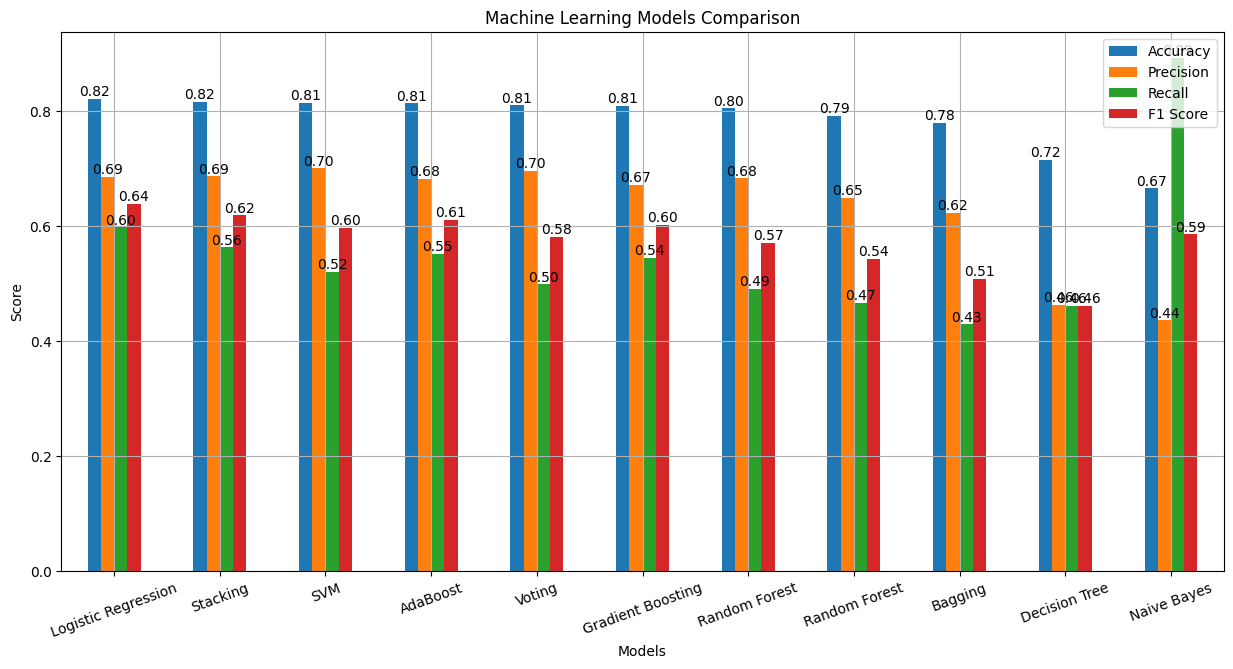

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# STORE RESULTS
# =========================================

results = []

# =========================================
# NORMAL MODELS
# =========================================

for name, model in models.items():

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    # Pipeline
    pipe = Pipeline([

        ('cleaning', FunctionTransformer(basic_cleaning)),

        ('preprocessing', preprocessor),

        ('model', model)

    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(y_test, y_pred)

    rec = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Print
    print("Accuracy :", acc)

    print("Precision:", prec)

    print("Recall   :", rec)

    print("F1 Score :", f1)

    # Store
    results.append({

        'Model': name,

        'Accuracy': acc,

        'Precision': prec,

        'Recall': rec,

        'F1 Score': f1

    })

# =========================================
# ENSEMBLE MODELS
# =========================================

for name, model in ensemble_models.items():

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    # Pipeline
    pipe = Pipeline([

        ('cleaning', FunctionTransformer(basic_cleaning)),

        ('preprocessing', preprocessor),

        ('model', model)

    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(y_test, y_pred)

    rec = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Print
    print("Accuracy :", acc)

    print("Precision:", prec)

    print("Recall   :", rec)

    print("F1 Score :", f1)

    # Store
    results.append({

        'Model': name,

        'Accuracy': acc,

        'Precision': prec,

        'Recall': rec,

        'F1 Score': f1

    })

# =========================================
# RESULTS TABLE
# =========================================

results_df = pd.DataFrame(results)

# Sort by Accuracy
results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n")
print(results_df)

# =========================================
# BEST MODEL
# =========================================

best_model = results_df.iloc[0]

print("\n")
print("Best Model :", best_model['Model'])

print("Best Accuracy :", best_model['Accuracy'])

# =========================================
# GRAPH
# =========================================

ax = results_df.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]].plot(

    kind='bar',

    figsize=(15,7)

)

plt.title("Machine Learning Models Comparison")

plt.ylabel("Score")

plt.xlabel("Models")

plt.xticks(rotation=20)

plt.grid(True)

plt.legend(loc='best')

# Value labels
for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%.2f'
    )

plt.show()

From your graph:

Model	Accuracy	Precision	Recall	F1
Logistic Regression	0.82	0.69	0.60	0.64
Stacking	0.82	0.69	0.56	0.62
SVM	0.81	0.70	0.52	0.60
AdaBoost	0.81	0.68	0.55	0.61
Voting	0.81	0.70	0.50	0.58
Gradient Boosting	0.81	0.67	0.54	0.60
Random Forest	0.80	0.68	0.49	0.57
Bagging	0.78	0.62	0.43	0.51
Decision Tree	0.72	0.47	0.46	0.46
Naive Bayes	0.67	0.44	0.89	0.59

In [ ]:
#Hence the logistic regression came out to be best model with high recall Highest Recall among strong models
# Highest F1 Score
# Highest Accuracy
# Stable and interpretable

In [80]:
import joblib

# =========================================
# LOGISTIC REGRESSION PIPELINE
# =========================================

logistic_pipe = Pipeline([

    ('cleaning', FunctionTransformer(basic_cleaning)),

    ('preprocessing', preprocessor),

    ('model', LogisticRegression())

])

# =========================================
# TRAIN MODEL
# =========================================

logistic_pipe.fit(X_train, y_train)

# =========================================
# EXPORT MODEL
# =========================================

joblib.dump(

    logistic_pipe,

    'logistic_churn_model.pkl'

)

print("Model exported successfully")

Model exported successfully


In [81]:


# =========================================
# LOAD SAVED MODEL
# =========================================

model = joblib.load(
    'logistic_churn_model.pkl'
)

# =========================================
# SAMPLE INPUT DATA
# =========================================

sample_data = pd.DataFrame({

    'customerID': ['7590-VHVEG'],   # optional

    'gender': ['Female'],

    'SeniorCitizen': [0],

    'Partner': ['Yes'],

    'Dependents': ['No'],

    'tenure': [12],

    'PhoneService': ['Yes'],

    'MultipleLines': ['No'],

    'InternetService': ['Fiber optic'],

    'OnlineSecurity': ['No'],

    'OnlineBackup': ['Yes'],

    'DeviceProtection': ['No'],

    'TechSupport': ['No'],

    'StreamingTV': ['Yes'],

    'StreamingMovies': ['Yes'],

    'Contract': ['Month-to-month'],

    'PaperlessBilling': ['Yes'],

    'PaymentMethod': ['Electronic check'],

    'MonthlyCharges': [85.5],

    'TotalCharges': [1026.0]

})

# =========================================
# REMOVE customerID IF EXISTS
# =========================================

if 'customerID' in sample_data.columns:

    sample_data = sample_data.drop(
        columns=['customerID']
    )

# =========================================
# PREDICTION
# =========================================

prediction = model.predict(sample_data)

# Probability
probability = model.predict_proba(sample_data)

# =========================================
# OUTPUT
# =========================================

print("Prediction :", prediction[0])

print("\nProbability:")

print(probability)

# Friendly Output
if prediction[0] == 1:

    print("\nCustomer is likely to CHURN")

else:

    print("\nCustomer is likely to STAY")

Prediction : 1

Probability:
[[0.29089513 0.70910487]]

Customer is likely to CHURN
